In [3]:
# importing all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, VotingRegressor, BaggingRegressor, StackingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
# loading data set

df = pd.read_csv("C:\\Knowledge Park\\AI, ML and DS\\ML_Deployment\\Life Expectancy\\Life Expectancy Data.csv")
df.head(3)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


In [7]:
# finding number of rows and columns in dataset
df.shape

(2938, 22)

In [8]:
# checking column names
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')

In [9]:
#stripping the leading and trailing spaces and replacing the spaces with underscore in column names
df.columns = df.columns.str.strip().str.replace(' ', '_')
df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='str')

In [11]:
#formating the column names to title case 
df.columns = df.columns.str.title()
df.columns

Index(['Country', 'Year', 'Status', 'Life_Expectancy', 'Adult_Mortality',
       'Infant_Deaths', 'Alcohol', 'Percentage_Expenditure', 'Hepatitis_B',
       'Measles', 'Bmi', 'Under-Five_Deaths', 'Polio', 'Total_Expenditure',
       'Diphtheria', 'Hiv/Aids', 'Gdp', 'Population', 'Thinness__1-19_Years',
       'Thinness_5-9_Years', 'Income_Composition_Of_Resources', 'Schooling'],
      dtype='str')

In [12]:
# checking for data set information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life_Expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   Infant_Deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   Percentage_Expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  Bmi                              2904 non-null   float64
 11  Under-Five_Deaths                2938 non-null   int64  
 12  Polio                          

In [ ]:
# two columns - "Country" and "Status" are categorical columns and rest all are numerical columns.(4 integer and 16 float columns) 
#missing values in the dataset
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life_Expectancy                     10
Adult_Mortality                     10
Infant_Deaths                        0
Alcohol                            194
Percentage_Expenditure               0
Hepatitis_B                        553
Measles                              0
Bmi                                 34
Under-Five_Deaths                    0
Polio                               19
Total_Expenditure                  226
Diphtheria                          19
Hiv/Aids                             0
Gdp                                448
Population                         652
Thinness__1-19_Years                34
Thinness_5-9_Years                  34
Income_Composition_Of_Resources    167
Schooling                          163
dtype: int64

In [19]:
#finding duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [20]:
#Life expectancy is the target variable and rest all are independent variables.
#removing null values rows from the data set where Life expectancy is null
df = df[df['Life_Expectancy'].notna()]
df.shape

(2928, 22)

In [21]:
# 10 rows are deleted from the dataset where Life expectancy is null. Now we have 2938 rows and 22 columns in the dataset.
# define numerical columns dataset
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Year', 'Life_Expectancy', 'Adult_Mortality', 'Infant_Deaths',
       'Alcohol', 'Percentage_Expenditure', 'Hepatitis_B', 'Measles', 'Bmi',
       'Under-Five_Deaths', 'Polio', 'Total_Expenditure', 'Diphtheria',
       'Hiv/Aids', 'Gdp', 'Population', 'Thinness__1-19_Years',
       'Thinness_5-9_Years', 'Income_Composition_Of_Resources', 'Schooling'],
      dtype='str')

In [24]:
#filling null values in the dataset with median of the respective columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()



Country                            0
Year                               0
Status                             0
Life_Expectancy                    0
Adult_Mortality                    0
Infant_Deaths                      0
Alcohol                            0
Percentage_Expenditure             0
Hepatitis_B                        0
Measles                            0
Bmi                                0
Under-Five_Deaths                  0
Polio                              0
Total_Expenditure                  0
Diphtheria                         0
Hiv/Aids                           0
Gdp                                0
Population                         0
Thinness__1-19_Years               0
Thinness_5-9_Years                 0
Income_Composition_Of_Resources    0
Schooling                          0
dtype: int64

In [26]:
#Null values are treated in the dataset
# now encode categorical columns "Country" and "Status" using LabelEncoder
# Country column has 193 unique values and Status column has 2 unique values. So we can use LabelEncoder to encode these two columns.
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])
df['Status'] = le.fit_transform(df['Status'])
df.head(3)

,Country,Year,Status,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Expenditure,Hepatitis_B,Measles,...,Polio,Total_Expenditure,Diphtheria,Hiv/Aids,Gdp,Population,Thinness__1-19_Years,Thinness_5-9_Years,Income_Composition_Of_Resources,Schooling
0,0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


In [63]:
# Model 1: Baseline Model without EDA
# 
df_model1 = df.copy()
df_model1.head(3)

,Country,Year,Status,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Expenditure,Hepatitis_B,Measles,...,Polio,Total_Expenditure,Diphtheria,Hiv/Aids,Gdp,Population,Thinness__1-19_Years,Thinness_5-9_Years,Income_Composition_Of_Resources,Schooling
0,0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


In [64]:
# defining target variable and independent variables
X = df_model1.drop('Life_Expectancy', axis=1)
Y = df_model1['Life_Expectancy']
print("Independent and Target variables are defined successfully")
print("Independent variables shape: ", X.shape)
print("Target variable shape: ", Y.shape)

Independent and Target variables are defined successfully
Independent variables shape:  (2928, 21)
Target variable shape:  (2928,)


In [65]:
# performing train test split on the dataset with 80% training data and 20% testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train Test Split is done successfully")
print("Training data shape: ", X_train.shape, Y_train.shape)
print("Testing data shape: ", X_test.shape, Y_test.shape)

Train Test Split is done successfully
Training data shape:  (2342, 21) (2342,)
Testing data shape:  (586, 21) (586,)


In [66]:
# List store Performance metrics of all models
model_names = []  

training_scores_r2 = []
training_scores_adj_r2 = []
training_scores_rmse = []

testing_scores_r2 = []
testing_scores_adj_r2 = []
testing_scores_rmse = []

In [67]:
# defining model evaluation function to calculate R2, Adjusted R2 and RMSE for training and testing data
def evaluate_model_performance(model, X_train, Y_train, X_test, Y_test):

    model.fit(X_train, Y_train) # tain the model on training data

    Y_train_pred = model.predict(X_train) # predict on training data
    Y_test_pred = model.predict(X_test) # predict on testing data

    training_r2 = r2_score(Y_train, Y_train_pred) # calculate R2 score for training data
    testing_r2 = r2_score(Y_test, Y_test_pred) # calculate R2 score for testing data

    n_train, p = X_train.shape
    n_test = X_test.shape[0]

    training_adj_r2 = 1 - (1 - training_r2) * (n_train - 1) / (n_train - p - 1) # calculate Adjusted R2 score for training data
    testing_adj_r2 = 1 - (1 - testing_r2) * (n_test - 1) / (n_test - p - 1) # calculate Adjusted R2 score for testing data

    training_rmse = np.sqrt(mean_squared_error(Y_train, Y_train_pred)) # calculate RMSE for training data
    testing_rmse = np.sqrt(mean_squared_error(Y_test, Y_test_pred)) # calculate RMSE for testing data

    # append the scores to the respective lists

    model_names.append(model.__class__.__name__)

    training_scores_r2.append(training_r2)
    training_scores_adj_r2.append(training_adj_r2)
    training_scores_rmse.append(training_rmse)

    testing_scores_r2.append(testing_r2)
    testing_scores_adj_r2.append(testing_adj_r2)
    testing_scores_rmse.append(testing_rmse)

    # print the scores
    print(f"Model: {model.__class__.__name__} Performance Metrics")

    print ("Training Performance Metrics")
    print(f"Training R2: {training_r2:.4f}")
    print(f"Training Adjusted R2: {training_adj_r2:.4f}")
    print(f"Training RMSE: {training_rmse:.4f}")

    print ("Testing Performance Metrics")
    print(f"Testing R2: {testing_r2:.4f}")
    print(f"Testing Adjusted R2: {testing_adj_r2:.4f}")
    print(f"Testing RMSE: {testing_rmse:.4f}")

In [69]:
# Estimators for Voting & Stacking

voting_estimators = [

    ('rf', RandomForestRegressor(random_state=42)),

    ('gbr', GradientBoostingRegressor(random_state=42)),

    ('xgb', XGBRegressor(random_state=42))
]


stacking_estimators = [

    ('rf', RandomForestRegressor(random_state=42)),

    ('gbr', GradientBoostingRegressor(random_state=42)),

    ('xgb', XGBRegressor(random_state=42))
]



# Regression Models


models = {

    "Linear Regression": LinearRegression(),  # Linear Regression is a linear approach to modeling the relationship between a dependent variable and one or more independent variables. It assumes that the relationship between the variables is linear, meaning that a change in the independent variable(s) will result in a proportional change in the dependent variable.

    "Ridge Regression": Ridge(), # Ridge Regression is a linear regression technique that adds a regularization term to the loss function to prevent overfitting. It shrinks the coefficients of less important features towards zero, which helps in reducing model complexity and improving generalization.

    "Lasso Regression": Lasso(), # Lasso Regression is a linear regression technique that adds a regularization term to the loss function to prevent overfitting. It shrinks the coefficients of less important features towards zero, which helps in reducing model complexity and improving generalization.

    "ElasticNet Regression": ElasticNet(), # ElasticNet Regression is a linear regression technique that combines the properties of both Ridge and Lasso regression. It adds a regularization term to the loss function that is a linear combination of the L1 and L2 penalties, allowing it to perform feature selection and shrinkage simultaneously.

    "Decision Tree": DecisionTreeRegressor(random_state=42), # Decision Tree is a non-linear/ tree-based model that splits the data into subsets based on the values of the input features. It creates a tree-like structure where each internal node represents a feature, each branch represents a decision rule, and each leaf node represents an outcome. Decision Trees can capture complex relationships in the data and are easy to interpret.

    "Random Forest": RandomForestRegressor(random_state=42), # Random Forest is a tree based modelthat combines multiple decision trees to make predictions. It reduces overfitting by averaging the predictions of individual trees, leading to better generalization.

    "AdaBoost": AdaBoostRegressor(random_state=42), # AdaBoost (Adaptive Boosting) is an ensemble learning technique that combines multiple weak learners (usually decision trees) to create a strong predictive model. It assigns weights to the training instances, giving more importance to the misclassified instances in each iteration, and combines the predictions of the weak learners to make a final prediction.

    "Gradient Boosting": GradientBoostingRegressor(random_state=42), # Gradient Boosting is an ensemble learning technique that builds a strong predictive model by combining multiple weak learners (usually decision trees) in a sequential manner. Each subsequent model is trained to correct the errors made by the previous models, and the final prediction is obtained by aggregating the predictions of all the weak learners.

    "Bagging Regressor": BaggingRegressor(random_state=42), # Bagging (Bootstrap Aggregating) is an ensemble learning technique that combines multiple instances of the same base model (usually decision trees) trained on different subsets of the training data. It reduces overfitting and improves model stability by averaging the predictions of the individual models.

    "XGBoost": XGBRegressor(random_state=42), # XGBoost (Extreme Gradient Boosting) is an optimized implementation of the gradient boosting algorithm that is designed to be highly efficient, flexible, and portable. It uses a combination of decision trees and gradient boosting to create a strong predictive model, and it includes additional features such as regularization, parallel processing, and handling missing values.

    "LightGBM": LGBMRegressor(random_state=42), # LightGBM (Light Gradient Boosting Machine) is a gradient boosting framework that uses tree-based learning algorithms. It is designed to be efficient and scalable, and it can handle large datasets with high-dimensional features. LightGBM uses a histogram-based approach to speed up the training process and reduce memory usage.

    "CatBoost": CatBoostRegressor(verbose=0, random_state=42), # CatBoost (Categorical Boosting) is a gradient boosting framework that is specifically designed to handle categorical features. It uses a combination of decision trees and gradient boosting to create a strong predictive model, and it includes additional features such as handling missing values, categorical feature encoding, and regularization.

    "KNN Regressor": KNeighborsRegressor(), # K-Nearest Neighbors (KNN) is a non-parametric, instance-based learning algorithm that predicts the target variable based on the average of the k-nearest neighbors in the feature space. It calculates the distance between the input data point and all other points in the training dataset, and selects the k closest points to make a prediction.

    "Support Vector Regressor": SVR(), # Support Vector Regression (SVR) is a regression technique that uses the principles of Support Vector Machines (SVM) to predict continuous target variables. It finds a hyperplane that best fits the data while allowing for some margin of error, and it can handle non-linear relationships by using kernel functions to transform the input features into a higher-dimensional space.

    "Voting Regressor": VotingRegressor(estimators=voting_estimators), # Voting Regressor is an ensemble learning technique that combines multiple regression models to make predictions. It takes the predictions of the individual models and combines them using a specified voting strategy (e.g., averaging) to produce a final prediction. Voting Regressor can improve model performance by leveraging the strengths of different models.

    "Stacking Regressor": StackingRegressor(estimators=stacking_estimators, final_estimator=LinearRegression()) # Stacking Regressor is an ensemble learning technique that combines multiple regression models to make predictions. It uses a two-level approach where the first level consists of multiple base models (the estimators) that make predictions on the input data, and the second level consists of a meta-model (the final estimator) that takes the predictions of the base models as input and makes a final prediction. Stacking Regressor can improve model performance by leveraging the strengths of different models.
    }

In [70]:
# training and evaluating all models
for model_name, model in models.items():
    print(f"Evaluating Model : {model_name}")
    print()
    evaluate_model_performance(
        model,
        X_train,
        Y_train,
        X_test,
        Y_test
    )

Evaluating Model : Linear Regression

Model: LinearRegression Performance Metrics
Training Performance Metrics
Training R2: 0.5779
Training Adjusted R2: 0.5741
Training RMSE: 6.2212
Testing Performance Metrics
Testing R2: 0.5713
Testing Adjusted R2: 0.5553
Testing RMSE: 6.0896
Evaluating Model : Ridge Regression

Model: Ridge Performance Metrics
Training Performance Metrics
Training R2: 0.8207
Training Adjusted R2: 0.8191
Training RMSE: 4.0547
Testing Performance Metrics
Testing R2: 0.8208
Testing Adjusted R2: 0.8141
Testing RMSE: 3.9373
Evaluating Model : Lasso Regression

Model: Lasso Performance Metrics
Training Performance Metrics
Training R2: 0.8112
Training Adjusted R2: 0.8095
Training RMSE: 4.1608
Testing Performance Metrics
Testing R2: 0.8085
Testing Adjusted R2: 0.8014
Testing RMSE: 4.0697
Evaluating Model : ElasticNet Regression

Model: ElasticNet Performance Metrics
Training Performance Metrics
Training R2: 0.8125
Training Adjusted R2: 0.8108
Training RMSE: 4.1460
Testing Pe

In [62]:
# Finally, we can create a DataFrame to store the performance metrics of all models for easy comparison and analysis.
performance_df = pd.DataFrame({
    'Model': model_names,
    'Training R2': training_scores_r2,
    'Testing R2': testing_scores_r2,
    'Training Adjusted R2': training_scores_adj_r2,
    'Testing Adjusted R2': testing_scores_adj_r2,
    'Training RMSE': training_scores_rmse,
    'Testing RMSE': testing_scores_rmse
})

model_performance_df = performance_df.sort_values(by='Testing R2', ascending=False).reset_index(drop=True)

model_performance_df

,Model,Training R2,Testing R2,Training Adjusted R2,Testing Adjusted R2,Training RMSE,Testing RMSE
0,StackingRegressor,0.998121,0.970083,0.998104,0.968969,4.150993e-01,1.608659
1,RandomForestRegressor,0.994753,0.968043,0.994706,0.966853,6.935838e-01,1.662618
2,VotingRegressor,0.992015,0.967337,0.991942,0.966121,8.556644e-01,1.680869
3,LGBMRegressor,0.991079,0.966733,0.990998,0.965495,9.044036e-01,1.696335
4,CatBoostRegressor,0.992864,0.966586,0.992800,0.965342,8.088556e-01,1.700086
5,XGBRegressor,0.999270,0.966206,0.999264,0.964948,2.586894e-01,1.709724
6,BaggingRegressor,0.992065,0.959392,0.991993,0.957880,8.529769e-01,1.874187
7,GradientBoostingRegressor,0.963346,0.950112,0.963014,0.948254,1.833236e+00,2.077328
8,DecisionTreeRegressor,1.000000,0.925672,1.000000,0.922904,2.543065e-16,2.535617
9,AdaBoostRegressor,0.911215,0.902566,0.910411,0.898938,2.853171e+00,2.903103


In [ ]:
# Stacking Regressor is the best model with highest Testing R2 score of 0.9055 and lowest Testing RMSE score of 3.88. It is followed by Gradient Boosting, Random Forest and XGBoost models with Testing R2 scores of 0.9039, 0.9036 and 0.9035 respectively.
# This is when we have not performed any EDA on the dataset. We can further improve the model performance by performing EDA and feature engineering on the dataset.

# Model 2: Model with EDA and Feature Engineering
## =========================================================

In [74]:
df_model2 = df.copy() # Create a copy of the original dataset for the second model
df_model2.head(3) # Check the first 3 rows of the second model's dataset

,Country,Year,Status,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Expenditure,Hepatitis_B,Measles,...,Polio,Total_Expenditure,Diphtheria,Hiv/Aids,Gdp,Population,Thinness__1-19_Years,Thinness_5-9_Years,Income_Composition_Of_Resources,Schooling
0,0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


In [75]:
df_model2.shape # Check the shape of the second model's dataset

(2928, 22)

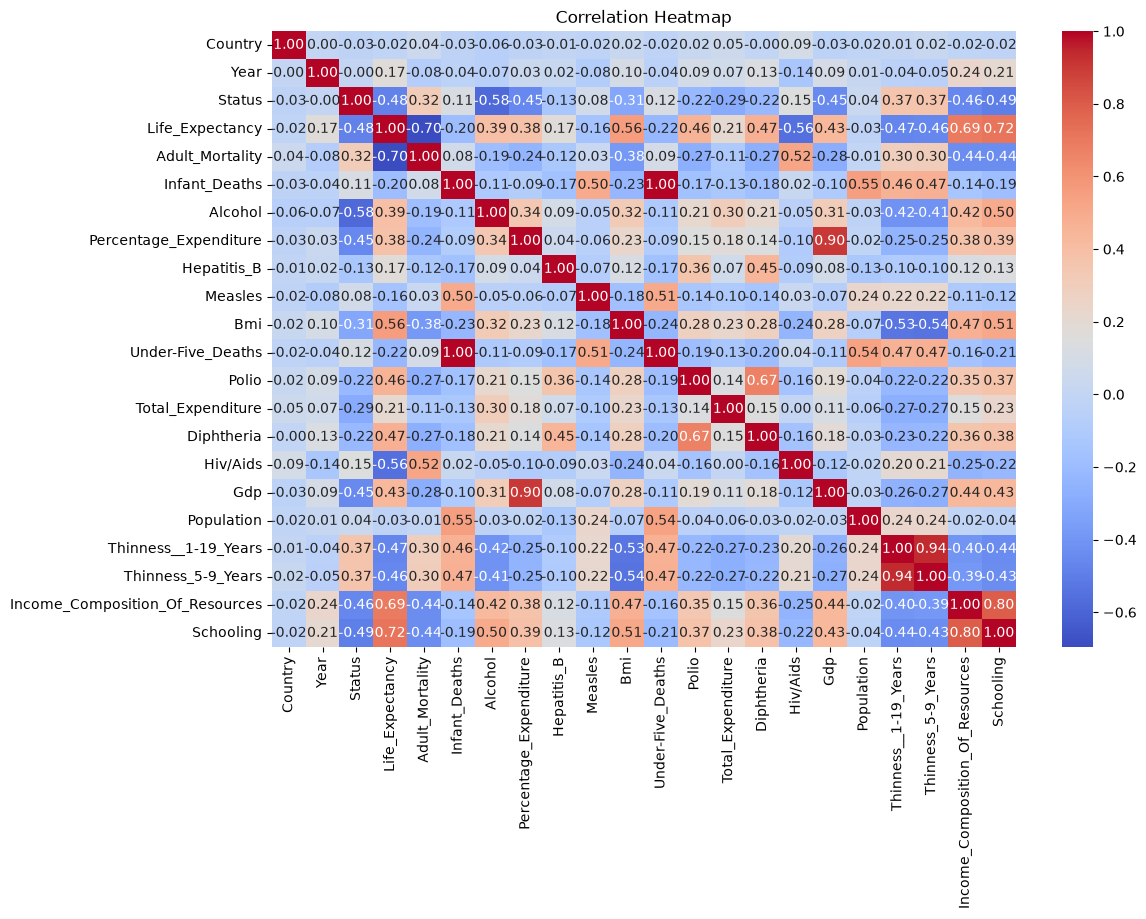

In [80]:
# plotting correlation heatmap to visualize the correlation between features and target variable

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_model2.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [81]:
# Countries with: higher education levels, better economic conditions, stronger healthcare systems, and better vaccination coverage 
# tend to have: higher life expectancy.

# Countries having lower life expecatancy are often characterized by: higher mortality rates, disease prevalance, malnutrition, 
# limited access to healthcare, and lower socioeconomic status. 

# Following features have strong correlation with with each other and indicate multicollinearity in the dataset:
# Thinness 1-19 Years <> Thinness 5-9 Years; 
# GDP <> Percentage Expenditure; 
# Schooling <> Income Composition of Resource

# Conclusion: The heatmap clearly demonstrates that: healthcare quality, vaccination coverage, economic strength, and education 
# are among the strongest determinants of life expectancy across countries.


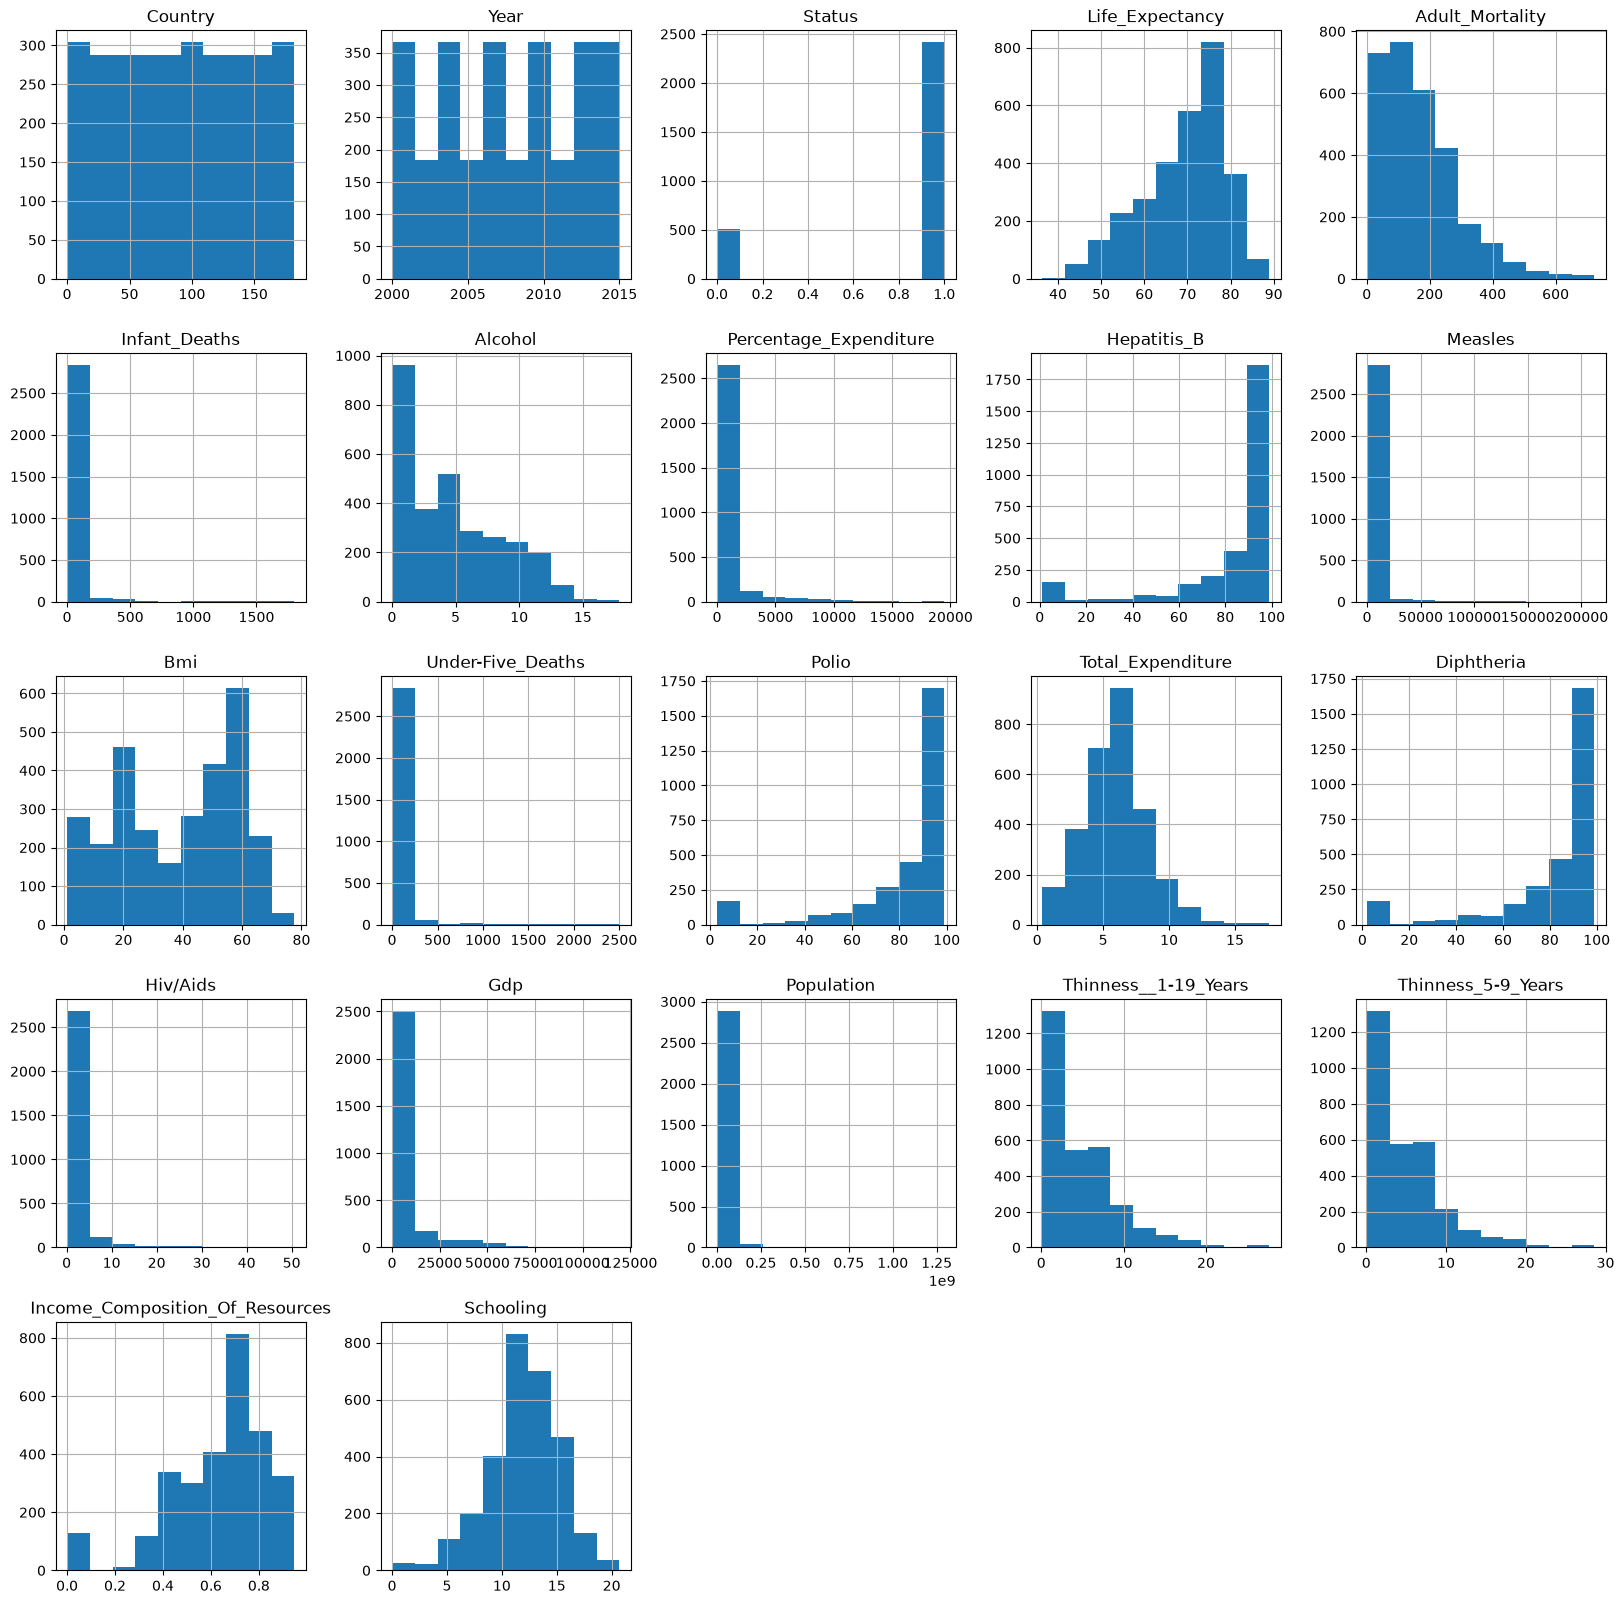

<Figure size 640x480 with 0 Axes>

In [83]:
# Histograms for numerical features to visualize their distributions
axes = df_model2.hist(figsize=(20, 20))
plt.show()
bins = 30

# 2. Loop through each subplot axis to add the KDE line
for ax in axes.flatten():
    # Only process subplots that actually contain data/plots
    if len(ax.get_lines()) == 0 and len(ax.patches) > 0:
        # Create a twin y-axis so the KDE density line fits perfectly
        ax_twin = ax.twinx()
        
        # Extract the column name from the title to plot its KDE
        col_name = ax.get_title()
        df_model2[col_name].plot(kind='kde', ax=ax_twin, color='red', linewidth=1.4)
        
        # Hide the secondary y-axis ticks to keep the look clean
        ax_twin.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

In [84]:
# Checking Skewness and Kurtosis for numerical features to understand their distributions

for col in df_model2.select_dtypes(include=[np.number]).columns:
    skewness = df_model2[col].skew()
    kurtosis = df_model2[col].kurtosis()
    print(f"{col}: Skewness = {skewness:.2f}, Kurtosis = {kurtosis:.2f}")


Country: Skewness = 0.00, Kurtosis = -1.20
Year: Skewness = 0.00, Kurtosis = -1.21
Status: Skewness = -1.71, Kurtosis = 0.93
Life_Expectancy: Skewness = -0.64, Kurtosis = -0.23
Adult_Mortality: Skewness = 1.17, Kurtosis = 1.75
Infant_Deaths: Skewness = 9.77, Kurtosis = 115.66
Alcohol: Skewness = 0.65, Kurtosis = -0.63
Percentage_Expenditure: Skewness = 4.64, Kurtosis = 26.48
Hepatitis_B: Skewness = -2.29, Kurtosis = 4.43
Measles: Skewness = 9.43, Kurtosis = 114.47
Bmi: Skewness = -0.24, Kurtosis = -1.29
Under-Five_Deaths: Skewness = 9.48, Kurtosis = 109.39
Polio: Skewness = -2.11, Kurtosis = 3.83
Total_Expenditure: Skewness = 0.62, Kurtosis = 1.34
Diphtheria: Skewness = -2.08, Kurtosis = 3.61
Hiv/Aids: Skewness = 5.39, Kurtosis = 34.77
Gdp: Skewness = 3.54, Kurtosis = 15.08
Population: Skewness = 17.94, Kurtosis = 379.87
Thinness__1-19_Years: Skewness = 1.73, Kurtosis = 4.05
Thinness_5-9_Years: Skewness = 1.79, Kurtosis = 4.44
Income_Composition_Of_Resources: Skewness = -1.21, Kurtosis

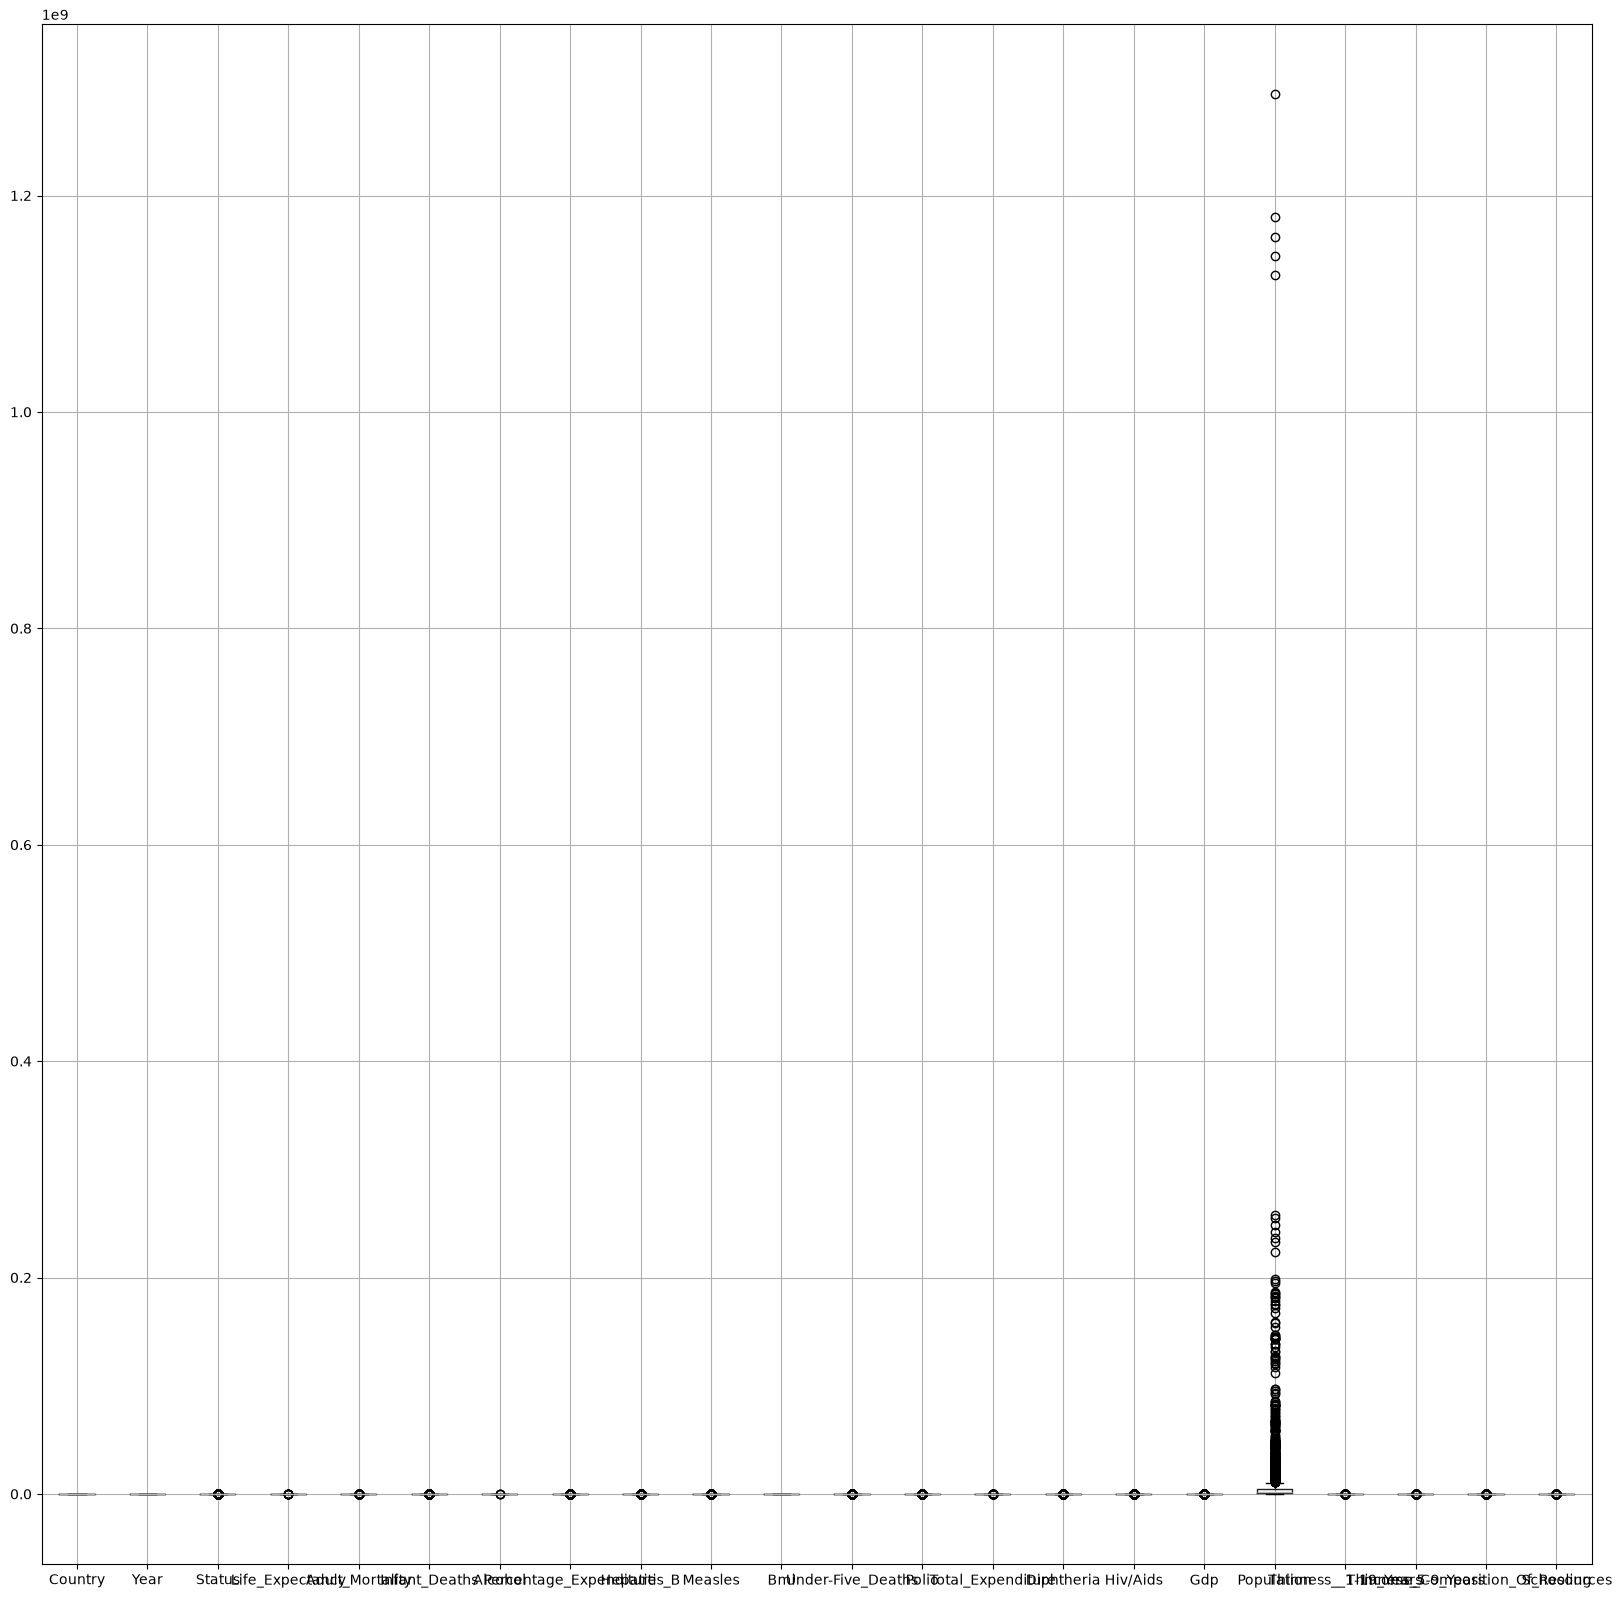

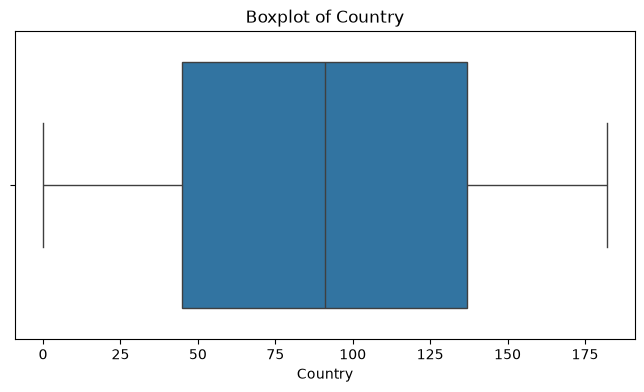

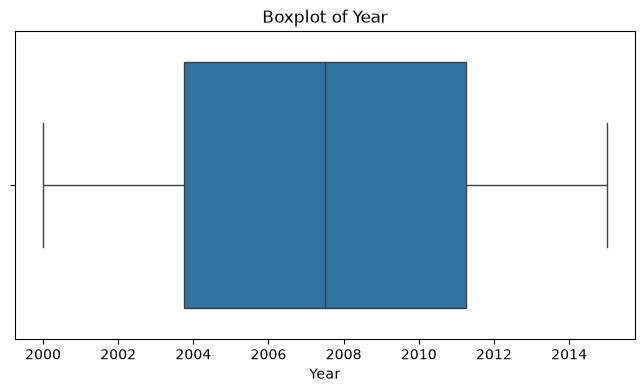

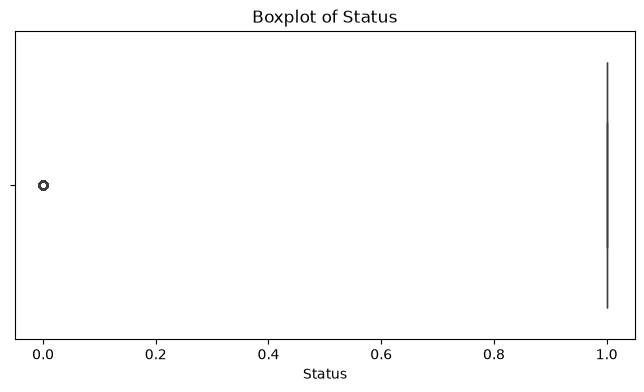

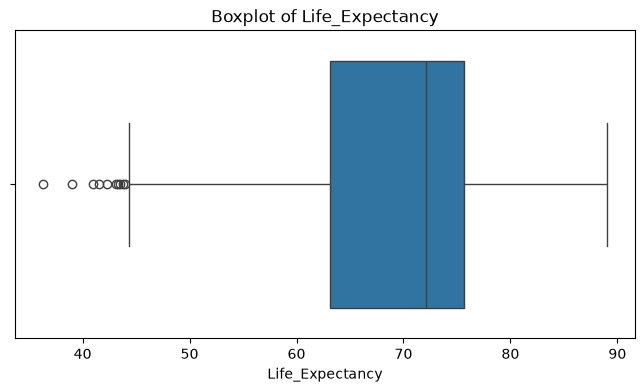

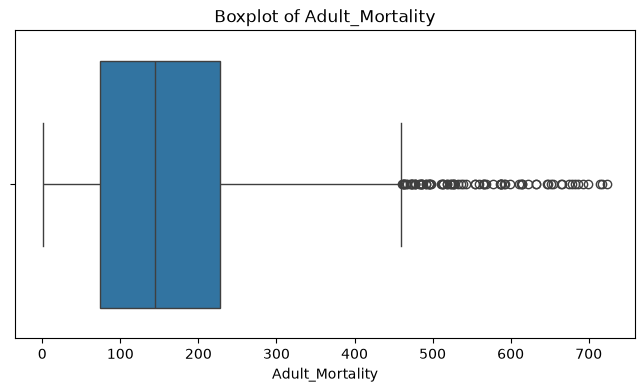

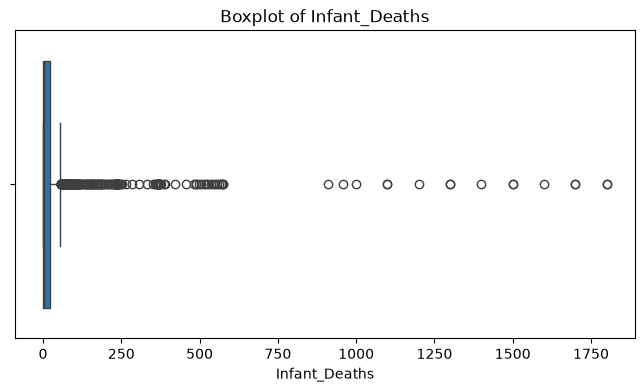

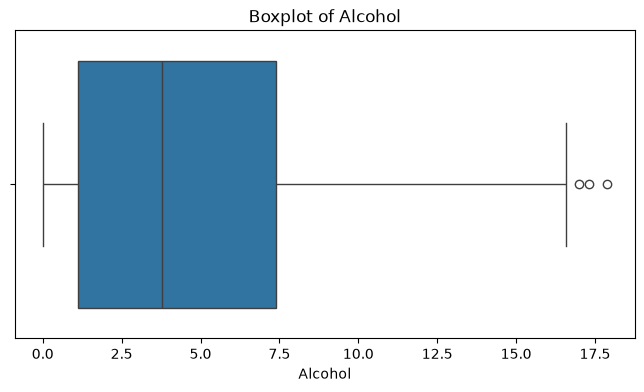

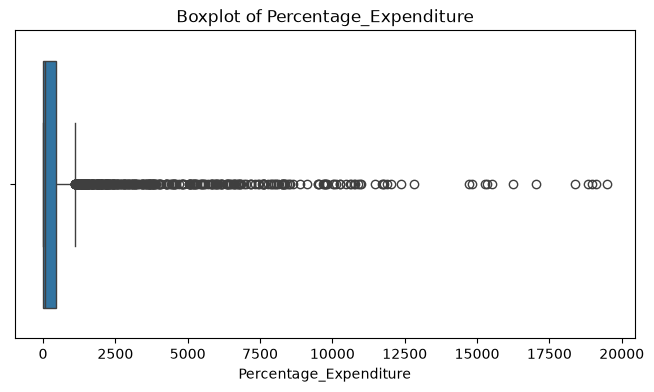

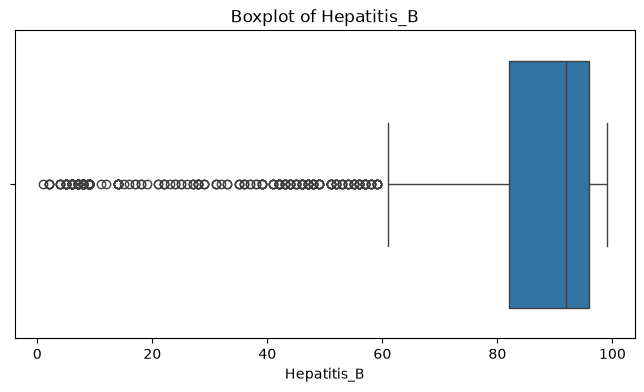

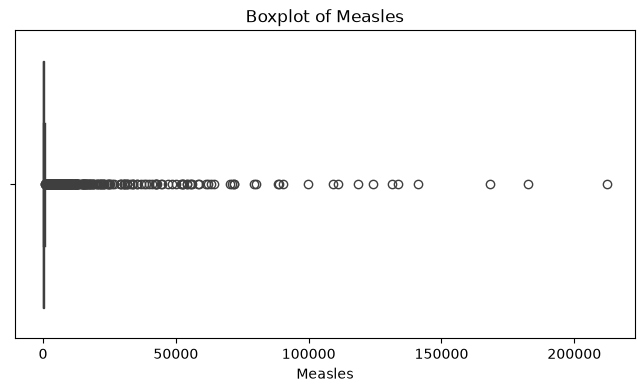

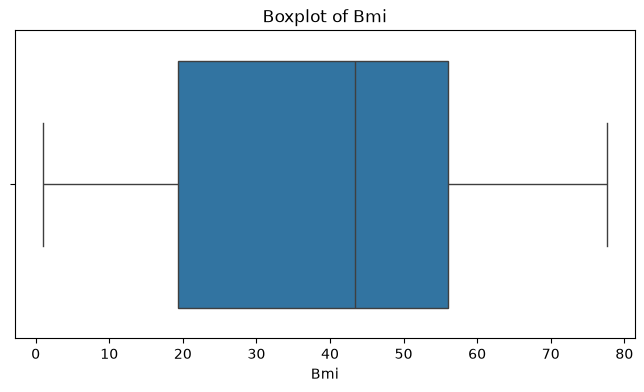

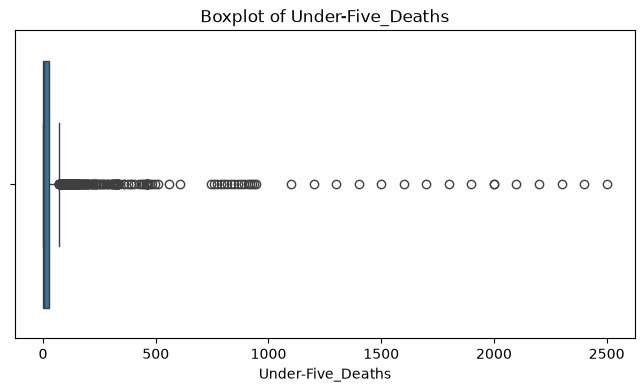

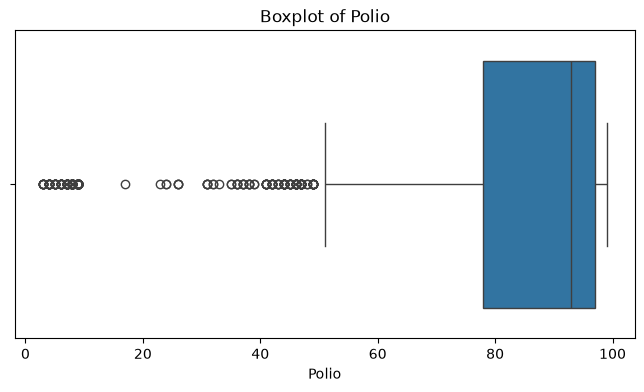

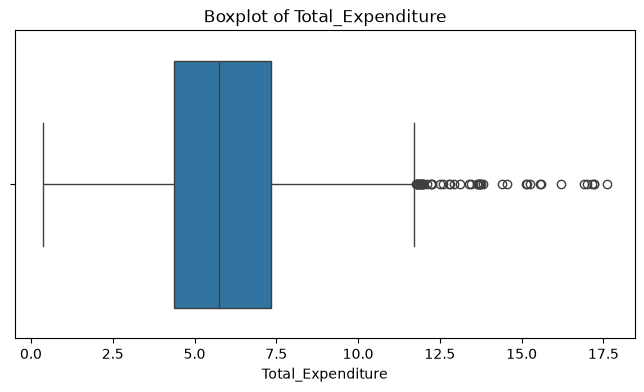

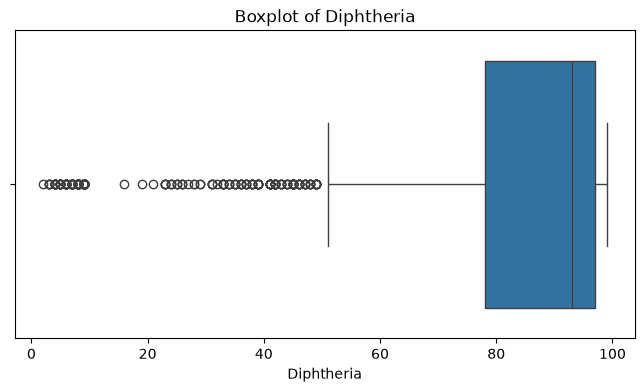

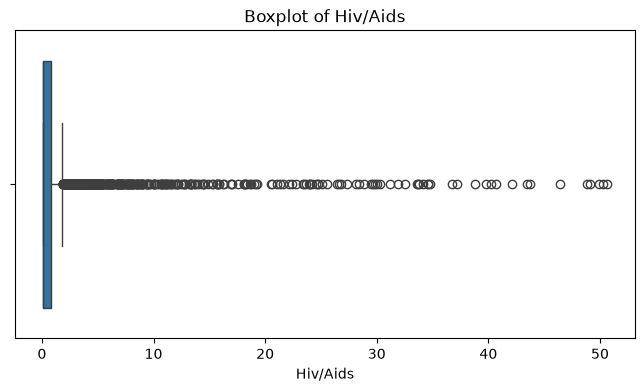

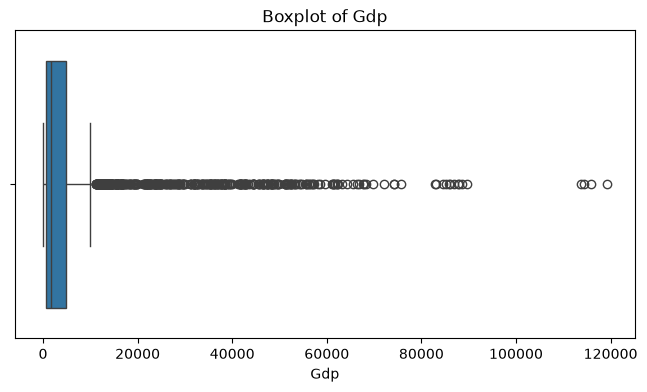

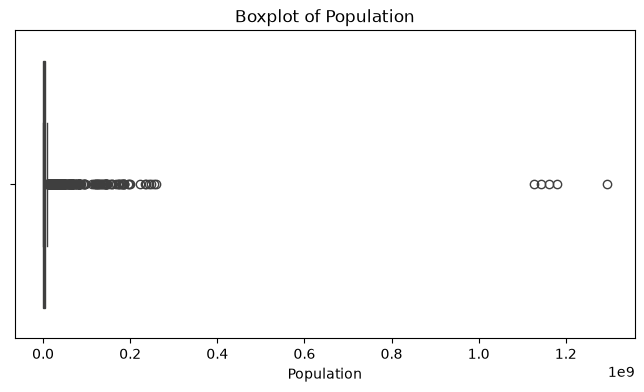

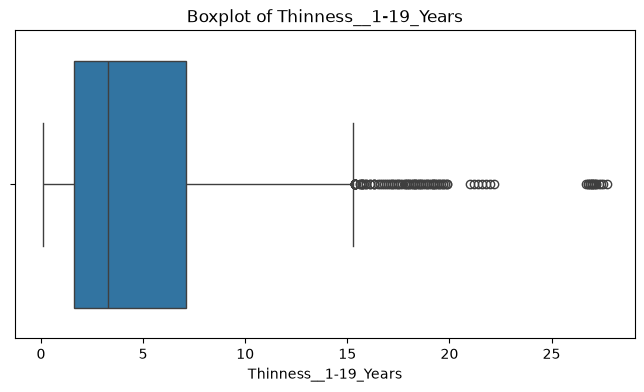

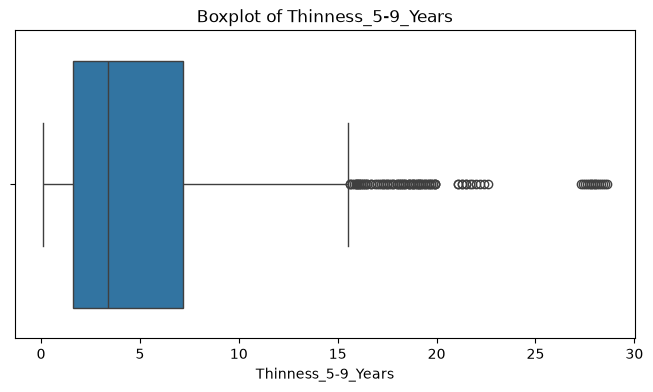

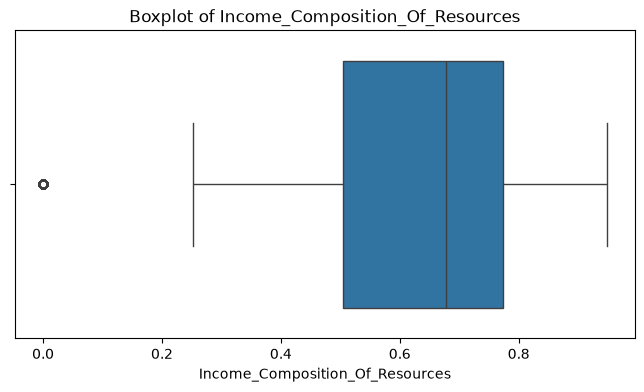

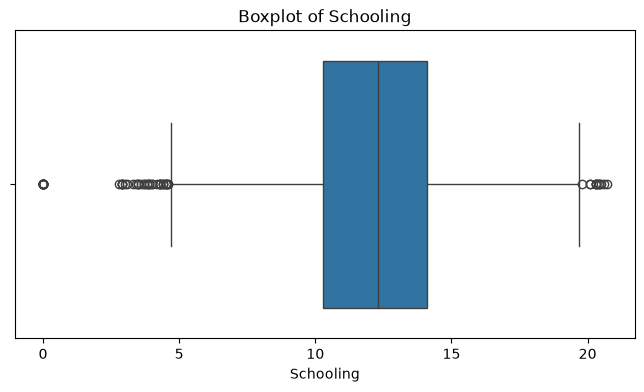

In [85]:
# Many variables are highly skewed and contained significant outliers.
# It is important to address these issues before training machine learning models, as they can negatively impact model performance.
# We will perform the following preprocessing steps to improve model performance: 
# skewness treatment, logarithmic transformations, outlier handling, and feature scaling.

# Boxplots for numerical features to visualize their distributions and identify outliers
df_model2.boxplot(figsize=(20, 20))

for i, col in enumerate(df_model2.select_dtypes(include=[np.number]).columns):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_model2[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
# Key Observations from Boxplot Analysis
# The boxplots revealed substantial outliers across multiple variables.

# Major variables containing heavy outliers included: 
# GDP
# Population
# Adult Mortality
# HIV/AIDS
# Measles
# Percentage Expenditure
# Infant Deaths
# Under-Five Deaths
# Hepatitis B
# Polio
# Total Expenditure
# Diphtheria
# Thinness 1-19 Years
# Thinness 5-9 Years